# 03 Parameter Sweep Atlas

This is the scalar design-space notebook. I now use the higher-resolution `publication` preset here because the heatmaps are where clipped axial scans and weak Nyquist margins can mislead me most. The main z metric is `bessel_region_um`, which intersects peak strength, ring/core power, and radius stability rather than only measuring the peak-trace FWHM.

## Stage 8.7 Adjustable Quick-Look Guidance

<!-- STAGE87: adjustable quicklook guidance -->

For fast parameter scouting, use `notebooks/quicklook/00_quick_beam_to_sample_simulator.ipynb`. This notebook remains on its locked stage path: existing execution logic, propagation-power labels, material-proxy caveats, and governance routing are unchanged.

Safe local edits are the explicit config variables already exposed by this notebook, or a copied exploratory run. Keep `fail` and `marginal` labels visible. If a displayed image is visually smoothed, treat that as display interpolation only; rerun balanced/publication sampling before numerical interpretation.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from vbb_study import setup_study, vbb_style

PATHS = setup_study.bootstrap(Path.cwd())
ROOT = PATHS["root"]
PUB_ROOT = PATHS["publication"]
LAB_ROOT = PATHS["modular_lab"]

import bessel_twin_core as bt
from Publication_Study import publication_diagnostics as pdiag

In [ ]:
# papermill parameters — edit here for local runs, or inject via:
#   papermill ... --parameters PRESET fast
# Default is 'publication' for paper-quality figures.
# Pass PRESET='fast' in triage/CI to avoid timeout (Stage 4 fix).
PRESET = "publication"


## Editable Notebook Controls

<!-- STAGE88: editable controls -->

This cell exposes the intended user-editable controls for exploratory runs. The locked stage logic below is preserved: changing these controls is for local investigation unless the notebook explicitly wires a value into a regenerated canonical output. Keep QA, caveats, and fail/marginal labels visible. For fast beam-to-sample exploration use the quicklook notebook; for publication-grade outputs use the locked stage runner.


In [ ]:
# STAGE88: visible editable controls for exploratory notebook use.
# Edit NOTEBOOK_CONTROLS below and re-run this cell to apply parameter
# overrides to `base` before running any study cell below.
from dataclasses import replace
from vbb_study.publication import notebook_controls as nb_controls
from vbb_study.config import um as _um

NOTEBOOK_CONTROLS = nb_controls.make_notebook_controls(
    stage='scalar',
    # ── edit these to override the base configuration ───────────────────────
    ell=3,
    target_core_diameter_um=3.0,
    target_bessel_length_um=150.0,
    objective_NA=0.45,
    blaze_period_px=20,
)

# Build a base config and wire control parameters into it.
base = bt.default_config("fast")
_p = NOTEBOOK_CONTROLS.parameters or {}
if "ell" in _p:
    base = replace(base, target=replace(base.target, ell=int(_p["ell"])))
if "target_core_diameter_um" in _p:
    base = replace(base, target=replace(base.target, target_core_diameter_m=float(_p["target_core_diameter_um"]) * _um))
if "target_bessel_length_um" in _p:
    base = replace(base, target=replace(base.target, target_bessel_length_m=float(_p["target_bessel_length_um"]) * _um))
if "objective_NA" in _p:
    base = replace(base, objective=replace(base.objective, NA=float(_p["objective_NA"])))
if "blaze_period_px" in _p:
    base = replace(base, slm=replace(base.slm, blaze_period_px=int(_p["blaze_period_px"])))

try:
    display(nb_controls.describe_controls(NOTEBOOK_CONTROLS))
except NameError:
    print(nb_controls.describe_controls(NOTEBOOK_CONTROLS).to_string(index=False))


In [ ]:
# Interactive quicklook — adjust sliders and click "Update plots".
# Runs a fast preview only; nothing is saved.
from vbb_study.publication import notebook_widgets as nbw

_panel = nbw.interactive_quicklook(base, method='holographic', preset='fast')
display(_panel)


In [2]:
# PHASE7: canonical schema import
# Imports the canonical scalar output schema helpers.
# source_schema_version is embedded in every row written to CSV.
from vbb_study.publication.tables import (
    SCALAR_OUTPUT_SCHEMA_VERSION,
    SCALAR_SUMMARY_COLUMNS,
    annotate_scalar_row,
    ordered_row,
    propagation_power_label as _power_label,
)
print(f"Scalar output schema version: {SCALAR_OUTPUT_SCHEMA_VERSION}")
print(f"Canonical columns: {len(SCALAR_SUMMARY_COLUMNS)} defined in tables.py")


Scalar output schema version: 2.0.0
Canonical columns: 30 defined in tables.py


In [3]:
# PHASE7: fast-preset caution
# This notebook was last executed with the 'fast' grid preset.
# The fast preset is a DIAGNOSTIC / DEBUG speed mode:
#   - small grid (N=512), coarse axial sampling
#   - may show propagation_power_label='fail' (>20% power drift)
#   - NOT suitable as the primary source for publication figures
#
# Publication preset improves propagation-power drift, but does NOT certify
# every case as publication-ready. Preserve propagation_power_label and inspect
# fail rows as numerical diagnostics or rerun with finer grid/sampling/model setup.
# See: tools/regen_scalar_shortlist.py --preset publication
#
# Cases with propagation_power_label='fail' MUST NOT be reported as
# publication-ready or hidden by threshold relaxation.
import os as _os
_rid = _os.environ.get("STRUCTURED_BEAM_RUN_ID", "interactive")
_preset_env = _os.environ.get("STRUCTURED_BEAM_PRESET", "fast")
print(f"[Phase7 caution] run_id={_rid!r}  preset={_preset_env!r}")
print("[Phase7 caution] Fast preset: results are diagnostic quality only.")
print("[Phase7 caution] Publication preset improves drift but may still leave fail cases.")


[Phase7 caution] run_id='20260603T200130Z'  preset='fast'
[Phase7 caution] Fast preset: results are diagnostic quality only.
[Phase7 caution] Publication preset improves drift but may still leave fail cases.


In [4]:
# PRESET is defined in the parameters cell above (default: 'publication').
# Papermill can override it: --parameters PRESET fast
PUB_OUT = pdiag.publication_output_tree(PATHS["outputs"])
base = bt.default_config(PRESET)


## Run Study Tables

I keep the study runners in the scalar engine, but I ask for the publication preset here so the axial region and sampling QA are computed on a longer, denser scan. The CSVs keep both the legacy `bessel_zone_um` and the stricter `bessel_region_um` so I can compare them rather than silently replacing one definition.

In [5]:
oat = bt.run_oat_sensitivity(base, preset=PRESET, save=False)
tradeoff = bt.run_tradeoff_map(base, preset=PRESET, save=False)
ell_family = bt.run_ell_family_comparison(base, preset=PRESET, save=False)
device_realism = bt.run_device_realism_ablation(base, preset=PRESET, save=False)
interface_depth = bt.run_interface_depth_sweep(base, preset=PRESET, save=False)
sampling = bt.run_sampling_feasibility_envelope(base, preset=PRESET, save=False)

import os as _os
_ATLAS_RUN_ID = _os.environ.get("STRUCTURED_BEAM_RUN_ID")
_ATLAS_GENERATED_AT_UTC = pd.Timestamp.now(tz="UTC").isoformat()

def _is_missing(value):
    try:
        return bool(pd.isna(value)) or value == ""
    except (TypeError, ValueError):
        return value == ""

def _atlas_with_native_schema(df, *, default_path=None):
    rows = []
    for row in df.copy().to_dict("records"):
        if _is_missing(row.get("preset")):
            row["preset"] = PRESET
        if default_path is not None and _is_missing(row.get("path")):
            row["path"] = default_path
        row["generated_at_utc"] = _ATLAS_GENERATED_AT_UTC
        row["source_schema_version"] = SCALAR_OUTPUT_SCHEMA_VERSION
        annotate_scalar_row(row, run_id=_ATLAS_RUN_ID, qa_status=str(row.get("qa_status") or "exploratory"))
        rows.append(ordered_row(row))
    return pd.DataFrame(rows)

oat = _atlas_with_native_schema(oat)
tradeoff = _atlas_with_native_schema(tradeoff)
ell_family = _atlas_with_native_schema(ell_family)
device_realism = _atlas_with_native_schema(device_realism)
interface_depth = _atlas_with_native_schema(interface_depth)
sampling = _atlas_with_native_schema(sampling, default_path="not_applicable_sampling_envelope")

_atlas_tables = {
    "oat_sensitivity_atlas": oat,
    "tradeoff_atlas": tradeoff,
    "ell_family_atlas": ell_family,
    "device_realism_atlas": device_realism,
    "interface_depth_atlas": interface_depth,
    "sampling_atlas": sampling,
}
for _subject, _df in _atlas_tables.items():
    _path = PUB_OUT["csv"] / vbb_style.csv_name(3, "sweep", _subject)
    _df.to_csv(_path, index=False)
    print(_path)

C:\PhD\Code\Publication_Study\outputs\csv\publication_study\03_sweep_oat_sensitivity_atlas.csv
C:\PhD\Code\Publication_Study\outputs\csv\publication_study\03_sweep_tradeoff_atlas.csv
C:\PhD\Code\Publication_Study\outputs\csv\publication_study\03_sweep_ell_family_atlas.csv
C:\PhD\Code\Publication_Study\outputs\csv\publication_study\03_sweep_device_realism_atlas.csv
C:\PhD\Code\Publication_Study\outputs\csv\publication_study\03_sweep_interface_depth_atlas.csv
C:\PhD\Code\Publication_Study\outputs\csv\publication_study\03_sweep_sampling_atlas.csv


## Sensitivity Ranking

The one-at-a-time sweep already carries a repeated normalised zone sensitivity column. Collapse it to one row per knob for a paper-ready ranking figure.

,knob,normalised_zone_sensitivity,abs_rank
11,target_bessel_length_um,5.068919e-01,5.068919e-01
5,target_core_diameter_um,3.660946e-01,3.660946e-01
36,blaze_period_px,-6.588349e-02,6.588349e-02
0,ell,2.320433e-02,2.320433e-02
30,slm_phase_bits,7.721937e-03,7.721937e-03
33,fill_factor,1.686142e-15,1.686142e-15
39,beam_radius_on_slm_mm,-4.436614e-16,4.436614e-16
24,rep_rate_kHz,4.178655e-16,4.178655e-16
27,scan_speed_mm_s,1.017123e-16,1.017123e-16
18,write_depth_um,-9.174021e-17,9.174021e-17


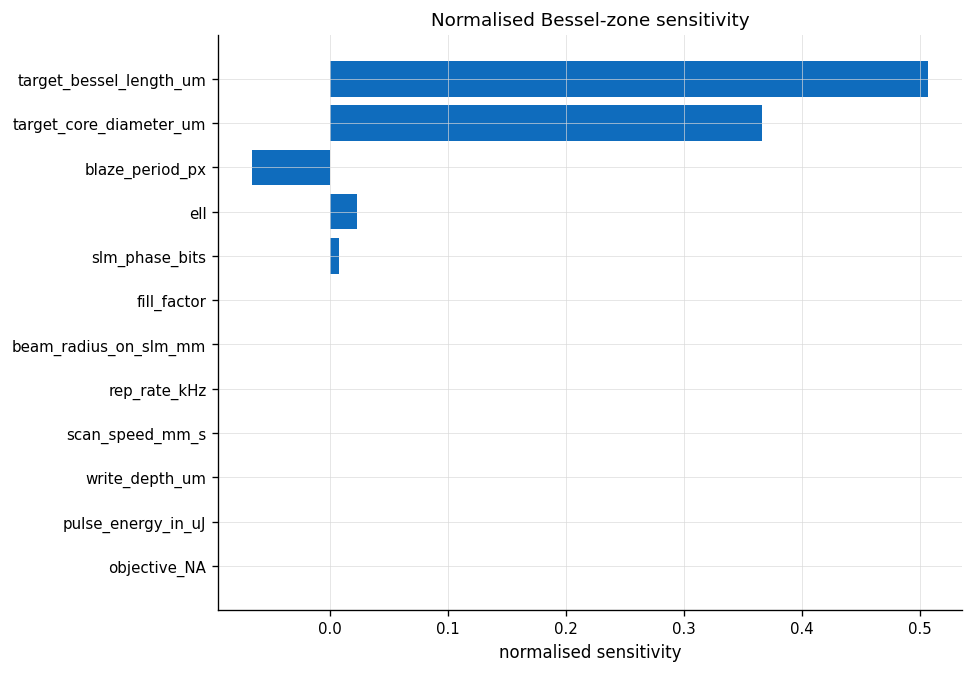

C:\PhD\Code\Publication_Study\outputs\figures\publication_study\oat_sensitivity_ranking.png


In [6]:
oat_ranked = (
    oat[["knob", "normalised_zone_sensitivity"]]
    .dropna()
    .drop_duplicates()
    .assign(abs_rank=lambda df: df["normalised_zone_sensitivity"].abs())
    .sort_values("abs_rank", ascending=True)
)
display(oat_ranked.sort_values("abs_rank", ascending=False))
fig, ax = plt.subplots(figsize=(8, 5.5), constrained_layout=True)
ax.barh(oat_ranked["knob"], oat_ranked["normalised_zone_sensitivity"], color="#0f6cbd")
ax.set_title("Normalised Bessel-zone sensitivity")
ax.set_xlabel("normalised sensitivity")
sens_path = PUB_OUT["figures"] / "oat_sensitivity_ranking.png"
fig.savefig(sens_path, dpi=220, bbox_inches="tight")
plt.show()
print(sens_path)

## Core-Length Heatmaps

These heatmaps extend the target-length axis and put the fabrication-planning z metric beside the older optical quantities. `bessel_region_um` is the region I would trust more: peak, fixed bucket power, and radius stability must all hold around the representative plane.

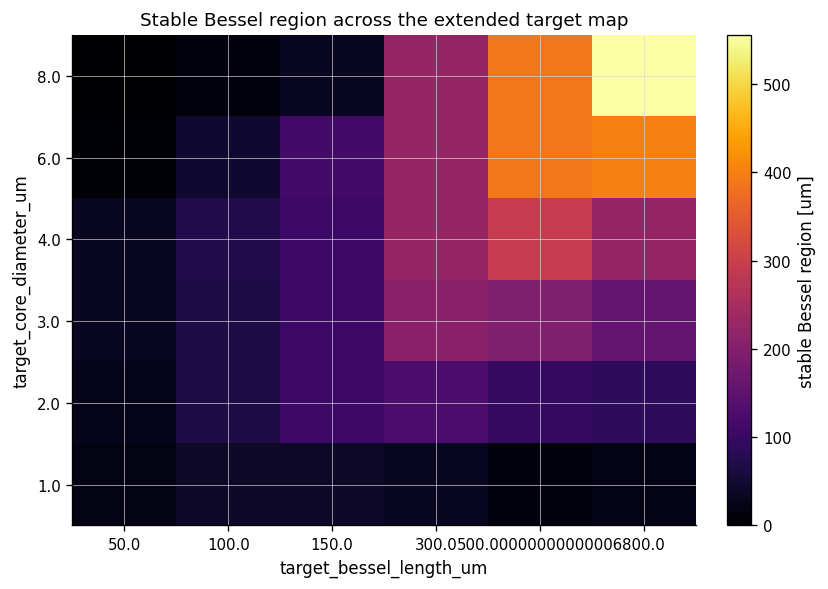

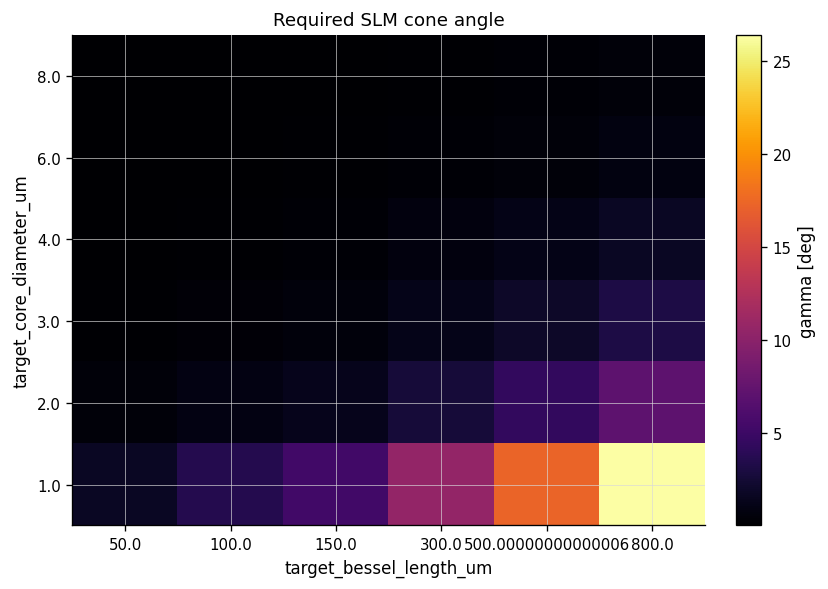

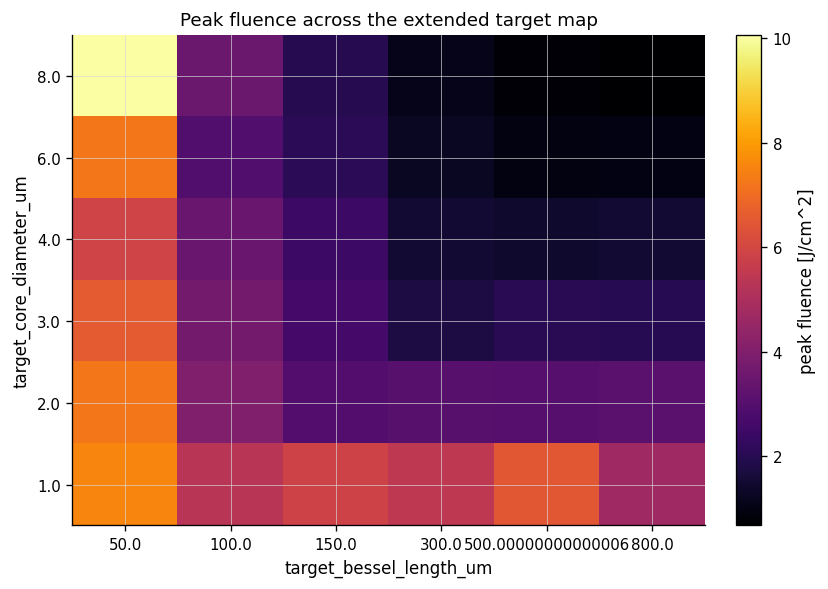

C:\PhD\Code\Publication_Study\outputs\figures\publication_study\03_sweep_stable_bessel_region_heatmap.png
C:\PhD\Code\Publication_Study\outputs\figures\publication_study\03_sweep_required_slm_cone_angle_heatmap.png
C:\PhD\Code\Publication_Study\outputs\figures\publication_study\03_sweep_peak_fluence_heatmap.png


In [7]:
fig_region = pdiag.plot_metric_heatmap(
    tradeoff,
    "target_core_diameter_um",
    "target_bessel_length_um",
    "bessel_region_um",
    "Stable Bessel region across the extended target map",
    "stable Bessel region [um]",
)
region_path = PUB_OUT["figures"] / vbb_style.figure_name(3, "sweep", "stable_bessel_region_heatmap")
vbb_style.save_figure(
    fig_region,
    region_path,
    "Stable Bessel-region heatmap across the extended core-diameter and target-length map. The metric intersects the peak-in-plane FWHM criterion with fixed ring/core power retention and radius-stability criteria, so it is stricter than the legacy peak-trace Bessel zone.",
    metadata={"metric": "bessel_region_um", "preset": PRESET},
)
plt.show()

fig1 = pdiag.plot_metric_heatmap(
    tradeoff,
    "target_core_diameter_um",
    "target_bessel_length_um",
    "gamma_slm_deg",
    "Required SLM cone angle",
    "gamma [deg]",
)
gamma_path = PUB_OUT["figures"] / vbb_style.figure_name(3, "sweep", "required_slm_cone_angle_heatmap")
vbb_style.save_figure(
    fig1,
    gamma_path,
    "Required holographic axicon cone angle across the extended target map. This panel is read alongside the sampling QA table because high cone angles push phase and focal-plane Nyquist margins.",
    metadata={"metric": "gamma_slm_deg", "preset": PRESET},
)
plt.show()

fig2 = pdiag.plot_metric_heatmap(
    tradeoff,
    "target_core_diameter_um",
    "target_bessel_length_um",
    "peak_fluence_J_cm2",
    "Peak fluence across the extended target map",
    "peak fluence [J/cm^2]",
)
fluence_path = PUB_OUT["figures"] / vbb_style.figure_name(3, "sweep", "peak_fluence_heatmap")
vbb_style.save_figure(
    fig2,
    fluence_path,
    "Peak fluence across the extended target map using the publication preset. Fluence is computed from the simulated plane intensity and the sample-side pulse energy budget, not hard-coded.",
    metadata={"metric": "peak_fluence_J_cm2", "preset": PRESET},
)
plt.show()

print(region_path)
print(gamma_path)
print(fluence_path)

## ell Family Scaling

Plot the annular footprint growth and the sample energy needed to reach the incubated threshold.

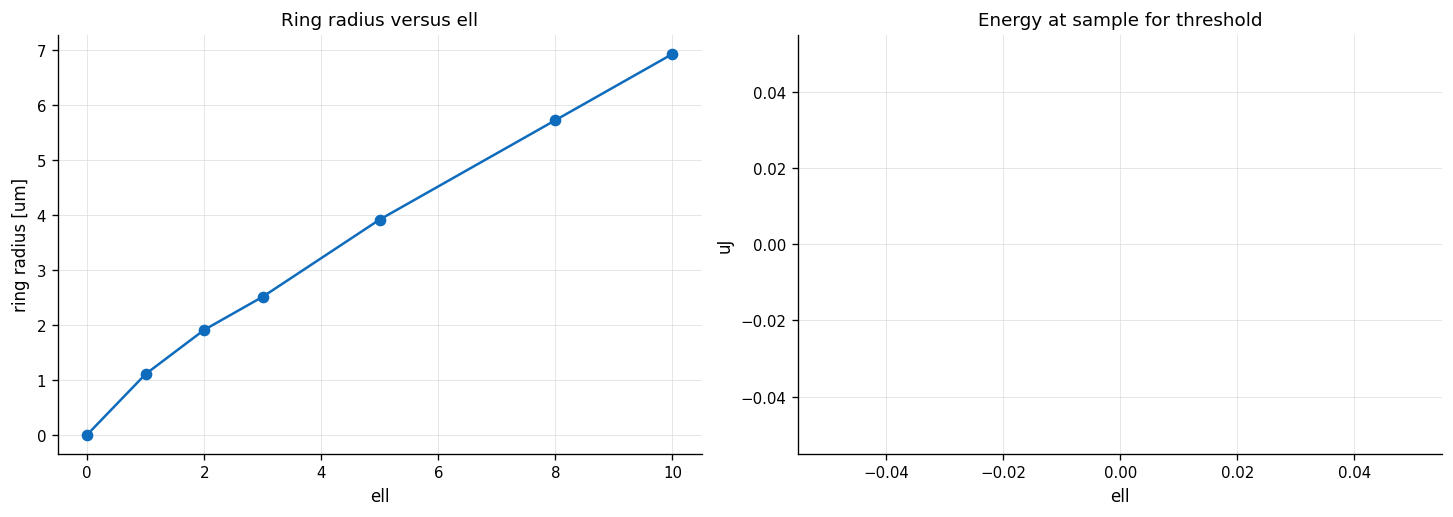

C:\PhD\Code\Publication_Study\outputs\figures\publication_study\ell_family_scaling.png


In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)
ax[0].plot(ell_family["ell"], ell_family["ring_radius_um"], marker="o", color="#0f6cbd")
ax[0].set_title("Ring radius versus ell")
ax[0].set_xlabel("ell")
ax[0].set_ylabel("ring radius [um]")
ax[1].plot(ell_family["ell"], ell_family["energy_at_sample_for_threshold_uJ"], marker="o", color="#c23934")
ax[1].set_title("Energy at sample for threshold")
ax[1].set_xlabel("ell")
ax[1].set_ylabel("uJ")
ell_path = PUB_OUT["figures"] / "ell_family_scaling.png"
fig.savefig(ell_path, dpi=220, bbox_inches="tight")
plt.show()
print(ell_path)

## Device Realism And Interface Depth

Summarise the staged realism penalty and the depth-dependent benefit of interface correction.

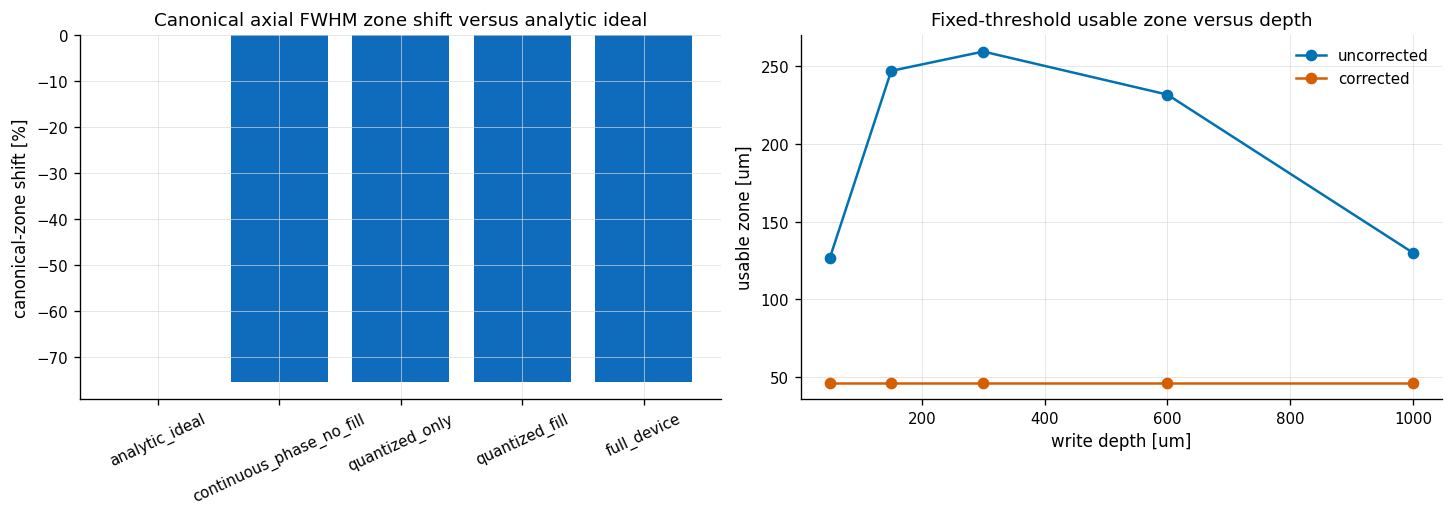

C:\PhD\Code\Publication_Study\outputs\figures\publication_study\device_realism_and_interface_depth.png


In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)
ax[0].bar(device_realism["case_id"], device_realism["canonical_zone_um_shift_vs_ideal_pct"], color="#0f6cbd")
ax[0].tick_params(axis="x", rotation=25)
ax[0].set_title("Canonical axial FWHM zone shift versus analytic ideal")
ax[0].set_ylabel("canonical-zone shift [%]")
for corrected, group in interface_depth.groupby("interface_corrected"):
    label = "corrected" if corrected else "uncorrected"
    ax[1].plot(group["write_depth_um"], group["absolute_half_ideal_zone_um"], marker="o", label=label)
ax[1].set_title("Fixed-threshold usable zone versus depth")
ax[1].set_xlabel("write depth [um]")
ax[1].set_ylabel("usable zone [um]")
ax[1].legend(frameon=False)
realism_path = PUB_OUT["figures"] / "device_realism_and_interface_depth.png"
fig.savefig(realism_path, dpi=220, bbox_inches="tight")
plt.show()
print(realism_path)

## Capability Slice

Take the mid-length slice at 150 um and map QA state over ell and target core diameter. This gives a quick publication figure for where the fast-preset envelope is clean, marginal, or failing.

,ell,target_core_diameter_um,qa_status,hardware_reachable,gamma_slm_deg
2,0,1.0,fail,True,5.317721
8,0,2.0,marginal,True,1.333020
14,0,3.0,marginal,True,0.592539
20,0,4.0,marginal,True,0.333311
26,0,6.0,marginal,True,0.148140
32,0,8.0,marginal,False,0.083329
38,1,1.0,fail,True,5.317721
44,1,2.0,marginal,True,1.333020
50,1,3.0,marginal,True,0.592539
56,1,4.0,marginal,True,0.333311


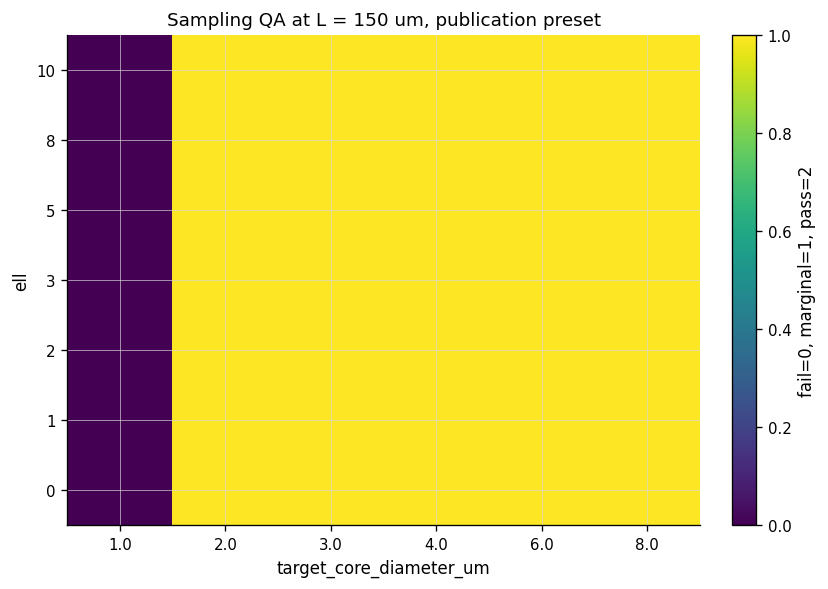

C:\PhD\Code\Publication_Study\outputs\figures\publication_study\sampling_capability_slice_L150.png


In [10]:
slice_df = sampling.loc[sampling["target_bessel_length_um"] == 150.0].copy()
slice_df["qa_score"] = slice_df["qa_status"].map({"fail": 0.0, "marginal": 1.0, "pass": 2.0})
display(slice_df[["ell", "target_core_diameter_um", "qa_status", "hardware_reachable", "gamma_slm_deg"]])
fig = pdiag.plot_metric_heatmap(slice_df, "ell", "target_core_diameter_um", "qa_score", "Sampling QA at L = 150 um, publication preset", "fail=0, marginal=1, pass=2", cmap="viridis")
capability_path = PUB_OUT["figures"] / "sampling_capability_slice_L150.png"
fig.savefig(capability_path, dpi=220, bbox_inches="tight")
plt.show()
print(capability_path)

In [11]:
# PHASE7: propagation power QA
# Check propagation power drift for all cases found in notebook global scope.
# pass <= 5%, marginal <= 20%, fail > 20%.
# Fast preset is diagnostic/debug only. Publication preset improves drift, but
# does not make every case publication-ready; fail rows stay visible and should
# be treated as numerical diagnostics or rerun with finer grid/sampling/model setup.
import pandas as pd  # noqa: F811 (safe re-import)
_found_qa = False
for _name in [
    "summary",
    "df",
    "shortlist_df",
    "summary_df",
    "comparison_table",
    "preset_comparison",
    "oat",
    "tradeoff",
    "ell_family",
    "device_realism",
    "interface_depth",
]:
    _df = globals().get(_name)
    if _df is not None and isinstance(_df, pd.DataFrame) and "propagation_power_label" in _df.columns:
        _qa_cols = ["preset", "case_id", "propagation_power_drift_fraction", "propagation_power_label"]
        _qa = _df[[c for c in _qa_cols if c in _df.columns]].copy()
        if "preset" not in _qa.columns:
            _qa["preset"] = globals().get("PRESET", "unknown")
        _summary = (
            _qa.groupby("preset", dropna=False)["propagation_power_label"]
            .value_counts()
            .unstack(fill_value=0)
            .reindex(columns=["pass", "marginal", "fail"], fill_value=0)
            .reset_index()
        )
        print(f"Power QA counts by preset for '{_name}':")
        print(_summary.to_string(index=False))
        _pass = int((_qa["propagation_power_label"] == "pass").sum())
        _marginal = int((_qa["propagation_power_label"] == "marginal").sum())
        _fail = int((_qa["propagation_power_label"] == "fail").sum())
        print(f"Power QA for '{_name}': {_pass} pass, {_marginal} marginal, {_fail} fail")
        if _fail > 0:
            print("WARNING: FAIL cases (>20% drift) are NOT suitable for publication figures.")
        if _marginal > 0:
            print("NOTE: MARGINAL cases (5-20% drift) — review before publication.")
        _found_qa = True
        break
if not _found_qa:
    print("NOTE: power QA cell ran — no scalar summary DataFrame found in scope yet.")
    print("      Re-run this cell AFTER the cell that builds 'summary' or 'shortlist_df'.")


Power QA counts by preset for 'oat':
     preset  pass  marginal  fail
publication     2        12    28
Power QA for 'oat': 2 pass, 12 marginal, 28 fail
NOTE: MARGINAL cases (5-20% drift) — review before publication.


In [12]:
# PHASE7: canonical zone vs strict region
# These are TWO DIFFERENT metrics. Never plot or report them interchangeably.
#
#   canonical_zone_um       = axial peak FWHM (single observable, broader)
#   strict_bessel_region_um = triple-intersection fabrication region (narrower)
#
# Use strict_bessel_region_um for fabrication planning and heatmaps.
# Use canonical_zone_um for optical diagnostic comparisons.
import pandas as pd  # noqa: F811
_zone_found = False
for _name in ["summary", "df", "shortlist_df", "summary_df", "oat", "tradeoff"]:
    _df = globals().get(_name)
    if _df is not None and isinstance(_df, pd.DataFrame):
        _c, _s = "canonical_zone_um", "strict_bessel_region_um"
        if _c in _df.columns and _s in _df.columns:
            _id = "case_id" if "case_id" in _df.columns else _df.columns[0]
            _z = _df[[_id, _c, _s]].copy()
            _z["zone_margin_um"] = _z[_c] - _z[_s]
            _z["strict_fraction"] = (_z[_s] / _z[_c].replace(0, float("nan"))).round(3)
            print(f"Zone/region comparison for '{_name}' ({len(_z)} rows):")
            print(_z.to_string(index=False))
            print()
            print("  canonical_zone_um       = axial_peak_fwhm  (from bessel_zone_metrics)")
            print("  strict_bessel_region_um = strict_intersection_peak_power_radius (narrower)")
            _zone_found = True
            break
if not _zone_found:
    print("NOTE: zone/region cell — no scalar summary DataFrame with both zone columns found.")
    print("      Re-run after the cell that builds 'summary' or 'shortlist_df'.")


Zone/region comparison for 'oat' (42 rows):
                      case_id  canonical_zone_um  strict_bessel_region_um  zone_margin_um  strict_fraction
                        ell_0         116.330912               106.666667        9.664245            0.917
                        ell_1         116.186896               106.666667        9.520229            0.918
                        ell_3         116.356812               106.666667        9.690145            0.917
                        ell_5         118.146288               106.666667       11.479622            0.903
                        ell_8         122.837788               100.000000       22.837788            0.814
  target_core_diameter_um_1p0          47.284931                40.000000        7.284931            0.846
  target_core_diameter_um_2p0         111.043850               106.666667        4.377184            0.961
  target_core_diameter_um_3p0         116.356812               106.666667        9.690145           